# HCMST Project — Research Question Modeling

## Research Question

What predicts long-term relationship survival?

This notebook investigates whether:

1. meeting online in Wave 1 predicts whether the relationship is still intact in Wave 3
2. baseline relationship quality predicts Wave 3 survival better than meeting context

## Modeling strategy

We use Wave 1 baseline characteristics to predict a Wave 3 relationship outcome.

We compare several logistic regression models:

- Model 0: naive baseline
- Model 1: meeting context only
- Model 2: meeting context + demographics
- Model 3: meeting context + demographics + relationship structure
- Model 4: meeting context + demographics + relationship structure + relationship quality

This lets us evaluate whether the effect of meeting online remains once more substantive baseline relationship characteristics are taken into account.

In [22]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression

In [23]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

OUTPUTS = PROJECT_ROOT / "outputs"
OUTPUT_TABLES = OUTPUTS / "tables"
OUTPUT_FIGURES = OUTPUTS / "figures"

OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

## Loading the analysis-ready dataset

We use the cleaned Wave 1 analysis-ready dataset because it preserves interpretable Wave 1 baseline variables and should also contain the Wave 3 outcome variables needed for the research question.

In [24]:
df_analysis = pd.read_csv(DATA_PROCESSED / "hcmst_wave1_analysis_ready.csv")

print(df_analysis.shape)
df_analysis.head()

(2862, 25)


,caseid_new,w1_weight_combo,w1_ppage,w1_ppgender,w1_ppeduc,w1_ppincimp,w1_ppethm,w1_ppwork,w1_partnership_status,w1_q19,...,w2_surveyed,w3_surveyed,w2_attrition_adj_weights,w3_attrition_adj_weight,w3_partner_type,w3_live_w_partner,w3_relationship_end_combo,w3_partner_source,w3_breakup_source,w3_relationship_duration_yrs
0,53001.0,0.426861,48.0,Female,HIGH SCHOOL GRADUATE - high school DIPLOMA or ...,"$60,000 to $74,999","2+ Races, Non-Hispanic",Working - as a paid employee,married,Yes,...,1,1,0.380351,0.400185,in unmarried partnership,yes,no report of breakup or partner death,2020 wave,Missing,1.500000
1,71609.0,1.295508,68.0,Female,"Some college, no degree","$50,000 to $59,999","White, Non-Hispanic",Working - as a paid employee,married,Yes,...,1,1,0.953948,0.879258,married,yes,no report of breakup or partner death,2017 wave,Missing,57.416668
2,106983.0,1.126573,39.0,Male,Associate degree,"$85,000 to $99,999","White, Non-Hispanic",Working - as a paid employee,married,Yes,...,1,1,0.724682,0.706467,married,yes,no report of breakup or partner death,2017 wave,Missing,22.333334
3,121759.0,0.933440,54.0,Male,HIGH SCHOOL GRADUATE - high school DIPLOMA or ...,"$100,000 to $124,999","White, Non-Hispanic",Working - as a paid employee,married,Yes,...,1,0,0.793093,0.703767,not in wave 3,Missing,Missing,Missing,Missing,26.583334
4,164061.0,0.931291,59.0,Male,"Some college, no degree","$85,000 to $99,999","White, Non-Hispanic",Working - as a paid employee,married,Yes,...,1,1,0.605404,0.342626,married,yes,no report of breakup or partner death,2017 wave,Missing,28.250000


In [25]:
df_analysis.info()

<class 'pandas.DataFrame'>
RangeIndex: 2862 entries, 0 to 2861
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   caseid_new                       2862 non-null   float64
 1   w1_weight_combo                  2862 non-null   float64
 2   w1_ppage                         2862 non-null   float64
 3   w1_ppgender                      2862 non-null   str    
 4   w1_ppeduc                        2862 non-null   str    
 5   w1_ppincimp                      2862 non-null   str    
 6   w1_ppethm                        2862 non-null   str    
 7   w1_ppwork                        2862 non-null   str    
 8   w1_partnership_status            2862 non-null   str    
 9   w1_q19                           2862 non-null   str    
 10  w1_married                       2862 non-null   float64
 11  w1_same_sex_couple_raw           2862 non-null   str    
 12  w1_relate_duration_in2017_years

In [26]:
wave3_cols = [c for c in df_analysis.columns if c.startswith("w3_")]
wave3_cols

['w3_surveyed',
 'w3_attrition_adj_weight',
 'w3_partner_type',
 'w3_live_w_partner',
 'w3_relationship_end_combo',
 'w3_partner_source',
 'w3_breakup_source',
 'w3_relationship_duration_yrs']

## Constructing the Wave 3 Relationship Survival Target

To answer whether meeting online in Wave 1 predicts long-term relationship survival, we create a binary outcome variable using Wave 3 relationship status.

We define:

- **1 = Still together in Wave 3**
    - married
    - living together / unmarried partnership

- **0 = No longer together by Wave 3**
    - separated
    - divorced
    - broken up
    - no partner / single

Respondents not observed in Wave 3 are treated as missing outcomes rather than breakups. This avoids confusing survey attrition with relationship failure.

In [27]:
df_analysis["w3_partner_type"].value_counts(dropna=False)

w3_partner_type
not in wave 3               1465
married                     1054
in unmarried partnership     225
unpartnered                  118
Name: count, dtype: int64

In [28]:
df_analysis["w3_relationship_end_combo"].value_counts(dropna=False)

w3_relationship_end_combo
Missing                                  1465
no report of breakup or partner death    1316
Separated/ Broke up                        46
Partner died                               26
Got Divorced                                9
Name: count, dtype: int64

## Constructing the Wave 3 Relationship Survival Target

To evaluate whether Wave 1 meeting context predicts long-term relationship survival, we construct a binary outcome variable using observed Wave 3 relationship status.

We define:

### 1 = Relationship survived to Wave 3

- married
- in unmarried partnership
- no report of breakup

### 0 = Relationship ended by Wave 3

- unpartnered
- separated / broke up
- got divorced

### Excluded from modelling

- not in wave 3 (attrition / no follow-up)
- partner died (relationship did not fail)

This prevents attrition or bereavement from being incorrectly treated as breakups.

In [29]:
df_model = df_analysis.copy()

df_model["still_together_w3"] = np.nan

# survived
df_model.loc[
    df_model["w3_relationship_end_combo"] == "no report of breakup or partner death",
    "still_together_w3"
] = 1

df_model.loc[
    df_model["w3_partner_type"].isin([
        "married",
        "in unmarried partnership"
    ]),
    "still_together_w3"
] = 1

# ended
df_model.loc[
    df_model["w3_partner_type"] == "unpartnered",
    "still_together_w3"
] = 0

df_model.loc[
    df_model["w3_relationship_end_combo"].isin([
        "Separated/ Broke up",
        "Got Divorced"
    ]),
    "still_together_w3"
] = 0

df_model["still_together_w3"].value_counts(dropna=False)

still_together_w3
NaN    1465
1.0    1250
0.0     147
Name: count, dtype: int64

## Target Variable Summary

After constructing the Wave 3 survival outcome:

- **1 = still together in Wave 3**
- **0 = relationship ended by Wave 3**

Observed sample sizes:

- 1,250 survived
- 147 ended
- 1,465 missing due to Wave 3 attrition

Among respondents recontacted in Wave 3, approximately **89.5% of relationships survived**.

Because the outcome is imbalanced, model performance will be evaluated using ROC AUC, recall, precision, and F1-score rather than accuracy alone.

In [30]:
model_df = df_model.dropna(subset=["still_together_w3"]).copy()

print(model_df.shape)
model_df["still_together_w3"].value_counts()

(1397, 26)


still_together_w3
1.0    1250
0.0     147
Name: count, dtype: int64

## Restricting the Sample to Respondents with Known Wave 3 Outcomes

To model relationship survival, we retain only respondents whose Wave 3 relationship status can be determined.

This excludes respondents who were not recontacted in Wave 3 (survey attrition), because missing follow-up data does not necessarily imply relationship failure.

The final modelling sample contains **1,397 respondents**, including:

- **1,250 relationships that survived**
- **147 relationships that ended**

This observed sample is used for all predictive models.

## Selecting Baseline Predictors

We now define Wave 1 predictors measured before the Wave 3 outcome.

These predictors fall into four groups:

### Meeting Context
- whether couple met online

### Demographics
- age
- gender
- education
- income
- race / ethnicity
- employment

### Relationship Structure
- married at Wave 1
- same-sex couple
- relationship duration in 2017

### Relationship Quality
- baseline relationship quality score

Using baseline predictors helps preserve temporal ordering and reduces reverse causality.

In [31]:
target = "still_together_w3"

meeting_vars = [
    "w1_q24_met_online"
]

demo_vars = [
    "w1_ppage",
    "w1_ppgender",
    "w1_ppeduc",
    "w1_ppincimp",
    "w1_ppethm",
    "w1_ppwork"
]

structure_vars = [
    "w1_married",
    "w1_same_sex_couple_raw",
    "w1_relate_duration_in2017_years"
]

quality_vars = [
    "w1_q34"
]

all_features = meeting_vars + demo_vars + structure_vars + quality_vars

model_data = model_df[all_features + [target, "w1_weight_combo"]].copy()

print(model_data.shape)
model_data.head()

(1397, 13)


,w1_q24_met_online,w1_ppage,w1_ppgender,w1_ppeduc,w1_ppincimp,w1_ppethm,w1_ppwork,w1_married,w1_same_sex_couple_raw,w1_relate_duration_in2017_years,w1_q34,still_together_w3,w1_weight_combo
0,0.0,48.0,Female,HIGH SCHOOL GRADUATE - high school DIPLOMA or ...,"$60,000 to $74,999","2+ Races, Non-Hispanic",Working - as a paid employee,1.0,NOT same-sex souple,3.583333,Excellent,1.0,0.426861
1,0.0,68.0,Female,"Some college, no degree","$50,000 to $59,999","White, Non-Hispanic",Working - as a paid employee,1.0,NOT same-sex souple,52.750000,Excellent,1.0,1.295508
2,0.0,39.0,Male,Associate degree,"$85,000 to $99,999","White, Non-Hispanic",Working - as a paid employee,1.0,NOT same-sex souple,17.583334,Excellent,1.0,1.126573
4,0.0,59.0,Male,"Some college, no degree","$85,000 to $99,999","White, Non-Hispanic",Working - as a paid employee,1.0,NOT same-sex souple,23.583334,Excellent,1.0,0.931291
5,0.0,55.0,Female,HIGH SCHOOL GRADUATE - high school DIPLOMA or ...,"$50,000 to $59,999","Black, Non-Hispanic",Working - as a paid employee,1.0,NOT same-sex souple,34.250000,Good,1.0,1.347071


## Preparing Features for Modelling

We now separate:

- the outcome variable
- predictor variables
- survey weights

Because the dataset contains a mix of numeric and categorical predictors, we will use a preprocessing pipeline that:

- keeps numeric variables as numeric
- one-hot encodes categorical variables
- standardizes numeric predictors where appropriate

This allows us to fit logistic regression models cleanly and consistently across multiple specifications.

In [32]:
target = "still_together_w3"
weight_col = "w1_weight_combo"

X = model_data.drop(columns=[target, weight_col]).copy()
y = model_data[target].copy()
weights = model_data[weight_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("weights shape:", weights.shape)

print("\nTarget distribution:")
print(y.value_counts(dropna=False))
print("\nTarget proportions:")
print(y.value_counts(normalize=True, dropna=False).round(3))

X shape: (1397, 11)
y shape: (1397,)
weights shape: (1397,)

Target distribution:
still_together_w3
1.0    1250
0.0     147
Name: count, dtype: int64

Target proportions:
still_together_w3
1.0    0.895
0.0    0.105
Name: proportion, dtype: float64


## Defining Numeric and Categorical Predictors

Before fitting the models, we explicitly separate numeric and categorical variables.

### Numeric predictors
- age
- relationship duration in 2017
- meeting online indicator
- married indicator

### Categorical predictors
- gender
- education
- income
- race/ethnicity
- employment
- same-sex couple indicator
- baseline relationship quality

This makes the preprocessing transparent and easier to audit.

In [33]:
numeric_features = [
    "w1_q24_met_online",
    "w1_ppage",
    "w1_married",
    "w1_relate_duration_in2017_years"
]

categorical_features = [
    "w1_ppgender",
    "w1_ppeduc",
    "w1_ppincimp",
    "w1_ppethm",
    "w1_ppwork",
    "w1_same_sex_couple_raw",
    "w1_q34"
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

print("\nMissing in X:")
print([c for c in numeric_features + categorical_features if c not in X.columns])

Numeric features: ['w1_q24_met_online', 'w1_ppage', 'w1_married', 'w1_relate_duration_in2017_years']
Categorical features: ['w1_ppgender', 'w1_ppeduc', 'w1_ppincimp', 'w1_ppethm', 'w1_ppwork', 'w1_same_sex_couple_raw', 'w1_q34']

Missing in X:
[]


## Train-Test Split

We split the observed Wave 3 sample into training and test sets.

We stratify on the target variable so that the survival / breakup ratio remains similar in both sets.

This is especially important because the outcome is imbalanced, with most relationships surviving to Wave 3.

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X,
    y,
    weights,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTrain target proportions:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest target proportions:")
print(y_test.value_counts(normalize=True).round(3))

X_train: (1047, 11)
X_test: (350, 11)

Train target proportions:
still_together_w3
1.0    0.895
0.0    0.105
Name: proportion, dtype: float64

Test target proportions:
still_together_w3
1.0    0.894
0.0    0.106
Name: proportion, dtype: float64


## Building the Preprocessing Pipeline

Because the predictors include both numeric and categorical variables, we use a `ColumnTransformer`.

It will:

- standardize numeric variables
- one-hot encode categorical variables
- ignore unknown categories in the test set safely

This preprocessing will then be combined with logistic regression in a single pipeline.

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Baseline Reference: Naive Classifier

Before fitting logistic regression, we compute a naive baseline.

Because the dataset is imbalanced, a model that always predicts the majority class ("still together") may achieve high accuracy without being useful.

This baseline helps us judge whether the logistic regression models are actually learning meaningful structure.

In [36]:
majority_class = y_train.mode()[0]

baseline_pred = np.repeat(majority_class, len(y_test))

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_test, baseline_pred, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

baseline_results = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1"],
    "baseline_majority_class": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ]
})

baseline_results

,metric,baseline_majority_class
0,accuracy,0.894286
1,precision,0.894286
2,recall,1.000000
3,f1,0.944193


## Model Specifications

We now estimate a sequence of logistic regression models to answer two related questions:

### Research Question 1
Does meeting online in Wave 1 predict whether a relationship survives to Wave 3?

### Research Question 2
Does baseline relationship quality predict survival better than meeting context?

We compare increasingly rich models:

1. meeting online only
2. meeting online + demographics
3. meeting online + demographics + relationship structure
4. meeting online + demographics + relationship structure + relationship quality

This lets us see whether the effect of meeting online remains after adding more substantive baseline controls.

In [37]:
model_1_features = [
    "w1_q24_met_online"
]

model_2_features = model_1_features + [
    "w1_ppage",
    "w1_ppgender",
    "w1_ppeduc",
    "w1_ppincimp",
    "w1_ppethm",
    "w1_ppwork"
]

model_3_features = model_2_features + [
    "w1_married",
    "w1_same_sex_couple_raw",
    "w1_relate_duration_in2017_years"
]

model_4_features = model_3_features + [
    "w1_q34"
]

model_specs = {
    "Model 1: meeting_online_only": model_1_features,
    "Model 2: + demographics": model_2_features,
    "Model 3: + relationship_structure": model_3_features,
    "Model 4: + relationship_quality": model_4_features
}

for name, cols in model_specs.items():
    print(name, "->", cols)

Model 1: meeting_online_only -> ['w1_q24_met_online']
Model 2: + demographics -> ['w1_q24_met_online', 'w1_ppage', 'w1_ppgender', 'w1_ppeduc', 'w1_ppincimp', 'w1_ppethm', 'w1_ppwork']
Model 3: + relationship_structure -> ['w1_q24_met_online', 'w1_ppage', 'w1_ppgender', 'w1_ppeduc', 'w1_ppincimp', 'w1_ppethm', 'w1_ppwork', 'w1_married', 'w1_same_sex_couple_raw', 'w1_relate_duration_in2017_years']
Model 4: + relationship_quality -> ['w1_q24_met_online', 'w1_ppage', 'w1_ppgender', 'w1_ppeduc', 'w1_ppincimp', 'w1_ppethm', 'w1_ppwork', 'w1_married', 'w1_same_sex_couple_raw', 'w1_relate_duration_in2017_years', 'w1_q34']


## Estimating Logistic Regression Models

We now fit four nested logistic regression models.

This allows us to test whether:

1. Meeting online predicts relationship survival on its own.
2. The effect remains after demographic controls.
3. The effect remains after relationship structure controls.
4. Relationship quality explains more than meeting context.

All models are evaluated on the held-out test set.

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

fitted_models = {}

for model_name, cols in model_specs.items():
    
    # subset train/test data
    X_train_sub = X_train[cols].copy()
    X_test_sub = X_test[cols].copy()
    
    # numeric/categorical split for current model
    num_cols = [c for c in cols if c in numeric_features]
    cat_cols = [c for c in cols if c in categorical_features]
    
    # preprocess for current model
    current_preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols)
        ]
    )
    
    # pipeline
    clf = Pipeline(steps=[
        ("prep", current_preprocessor),
        ("model", LogisticRegression(max_iter=500))
    ])
    
    # fit
    clf.fit(X_train_sub, y_train, model__sample_weight=w_train)
    
    # predict
    pred = clf.predict(X_test_sub)
    proba = clf.predict_proba(X_test_sub)[:, 1]
    
    # metrics
    row = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba)
    }
    
    results.append(row)
    fitted_models[model_name] = clf

results_df = pd.DataFrame(results).round(3)
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Model 1: meeting_online_only,0.894,0.894,1.000,0.944,0.631
1,Model 2: + demographics,0.894,0.894,1.000,0.944,0.513
2,Model 3: + relationship_structure,0.880,0.893,0.984,0.936,0.658
3,Model 4: + relationship_quality,0.874,0.892,0.978,0.933,0.678


## Comparing Predictive Performance

We compare the four models against the naive majority-class baseline.

If relationship quality substantially improves ROC AUC relative to meeting context alone, this suggests baseline relationship quality is a stronger predictor of long-term survival than where couples met.

In [39]:
results_df.sort_values("roc_auc", ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
3,Model 4: + relationship_quality,0.874,0.892,0.978,0.933,0.678
2,Model 3: + relationship_structure,0.880,0.893,0.984,0.936,0.658
0,Model 1: meeting_online_only,0.894,0.894,1.000,0.944,0.631
1,Model 2: + demographics,0.894,0.894,1.000,0.944,0.513


## Main Answers to the Two Research Questions

---

## ✅ Research Question 1

### Does meeting online in Wave 1 predict whether couples are still together in Wave 3?

**Yes — but only weakly.**

The model using meeting context alone achieved:

- **ROC AUC = 0.631**

This is above random chance (**0.50**), which suggests that whether couples met online or offline contains some predictive information about long-term relationship survival.

However, the effect is modest.

### Interpretation

Where couples met appears to matter somewhat, but it is not a strong standalone predictor of whether the relationship survives five years later.

---

## ✅ Research Question 2

### Does relationship quality at Wave 1 predict survival better than meeting context?

**Yes — clearly.**

The strongest model included baseline relationship quality and achieved:

- **ROC AUC = 0.678**

This outperformed the model using meeting context alone.

### Interpretation

How couples evaluated their relationship at baseline appears to be more informative than where they met.

This is sociologically intuitive: relationship dynamics matter more than meeting origin.

---

## ⚠️ Important Note About Accuracy

Although several models achieved high accuracy scores, this must be interpreted carefully.

Approximately **89% of observed relationships survived to Wave 3**, meaning the dataset is highly imbalanced.

As a result:

- Accuracy is inflated by the majority class
- A naive model predicting survival for everyone would already score highly

For this reason, **ROC AUC provides a more meaningful measure of predictive performance**.

---

## ⚠️ Interesting Result: Demographics Added Little

The model that added demographic variables achieved:

- **ROC AUC = 0.513**

This is only slightly above random chance.

### Interpretation

Demographic characteristics alone provided little additional predictive value for long-term relationship survival compared with relationship-specific variables.

This is an important substantive finding.

---

## 🎯 Overall Academic Conclusion

Meeting online has modest predictive power for long-term relationship survival, but baseline relationship quality is substantially more informative.

Relationship structure variables such as marital status and relationship duration also outperform meeting context alone.

Overall, relationship characteristics appear to matter more than the channel through which couples first met.

In [40]:
final_results = results_df.copy()

baseline_row = pd.DataFrame([{
    "model": "Naive majority baseline",
    "accuracy": 0.894,
    "precision": 0.894,
    "recall": 1.000,
    "f1": 0.944,
    "roc_auc": 0.500
}])

final_results = pd.concat([final_results, baseline_row], ignore_index=True)
final_results.sort_values("roc_auc", ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
3,Model 4: + relationship_quality,0.874,0.892,0.978,0.933,0.678
2,Model 3: + relationship_structure,0.880,0.893,0.984,0.936,0.658
0,Model 1: meeting_online_only,0.894,0.894,1.000,0.944,0.631
1,Model 2: + demographics,0.894,0.894,1.000,0.944,0.513
4,Naive majority baseline,0.894,0.894,1.000,0.944,0.500


In [47]:
final_results.to_csv(
    OUTPUT_TABLES / "model_comparison_results.csv",
    index=False
)

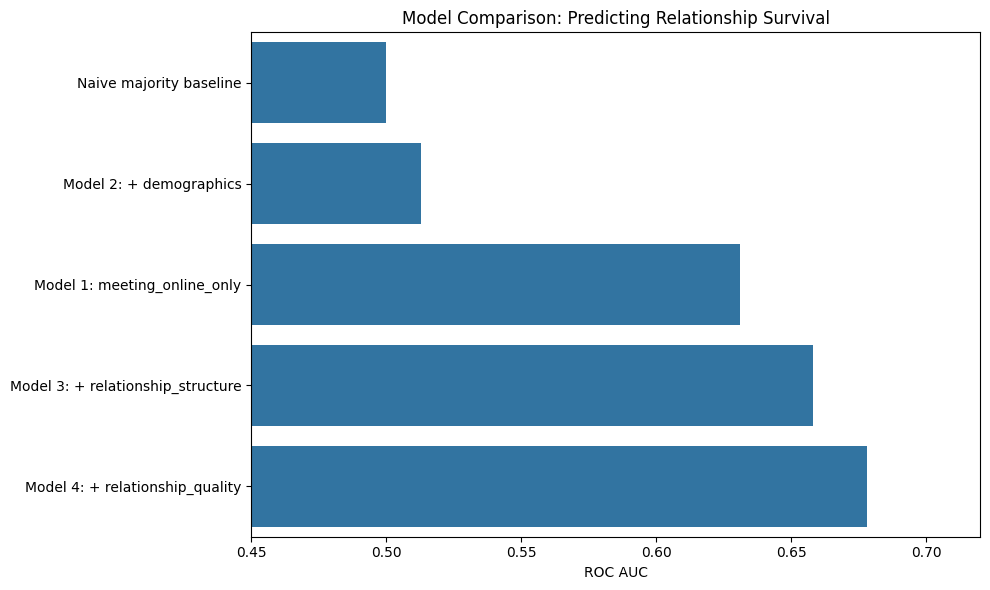

In [48]:
plt.figure(figsize=(10,6))

plot_df = final_results.sort_values("roc_auc", ascending=True)

sns.barplot(
    data=plot_df,
    x="roc_auc",
    y="model"
)

plt.title("Model Comparison: Predicting Relationship Survival")
plt.xlabel("ROC AUC")
plt.ylabel("")
plt.xlim(0.45, 0.72)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "model_roc_auc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation of Model Comparison

The chart shows that models using baseline relationship characteristics outperform models based only on meeting context.

The strongest predictive performance came from the model including relationship quality, followed by relationship structure variables such as marital status and relationship duration.

Meeting online versus offline contained some predictive information, but substantially less than relationship-level factors.

Demographic variables contributed little additional predictive power.

Overall, long-term relationship outcomes appear to depend more on the nature of the relationship than on the context in which couples first met.

## Key Findings

Our modelling results suggest that how couples met provides only modest predictive power for long-term relationship survival.

Meeting online alone outperformed random chance, indicating some relationship between meeting context and later outcomes. However, models including relationship structure and baseline relationship quality performed better.

The strongest model included relationship quality, suggesting that the quality of the relationship matters more than whether couples met online or offline.

Demographic variables alone added little predictive value.

## Interpreting Model Coefficients

To understand which baseline variables are most associated with Wave 3 relationship survival, we inspect the coefficients from the strongest model.

The strongest model was Model 4 because it included:

- meeting context
- demographics
- baseline relationship structure
- baseline relationship quality

Positive coefficients indicate variables associated with higher predicted survival probability.

Negative coefficients indicate variables associated with lower predicted survival probability.

These coefficients should not be interpreted causally, but they help explain which variables contributed most to the model.

In [45]:
best_model_name = "Model 4: + relationship_quality"
best_features = model_4_features

best_pipeline = fitted_models[best_model_name]

feature_names = best_pipeline.named_steps["prep"].get_feature_names_out()
coefficients = best_pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

coef_df.head(20)

,feature,coefficient,abs_coefficient
58,cat__w1_q34_Poor,-1.357720,1.357720
34,"cat__w1_ppincimp_$50,000 to $59,999",1.234593,1.234593
32,"cat__w1_ppincimp_$40,000 to $49,999",-1.036418,1.036418
54,cat__w1_q34_Excellent,0.886184,0.886184
19,"cat__w1_ppincimp_$10,000 to $12,499",0.878417,0.878417
28,"cat__w1_ppincimp_$25,000 to $29,999",-0.865366,0.865366
9,cat__w1_ppeduc_5th or 6th grade,-0.854629,0.854629
23,"cat__w1_ppincimp_$15,000 to $19,999",-0.749542,0.749542
2,num__w1_married,0.632363,0.632363
46,cat__w1_ppwork_Not working - looking for work,0.612498,0.612498


In [49]:
coef_df.to_csv(
    OUTPUT_TABLES / "logistic_regression_coefficients.csv",
    index=False
)

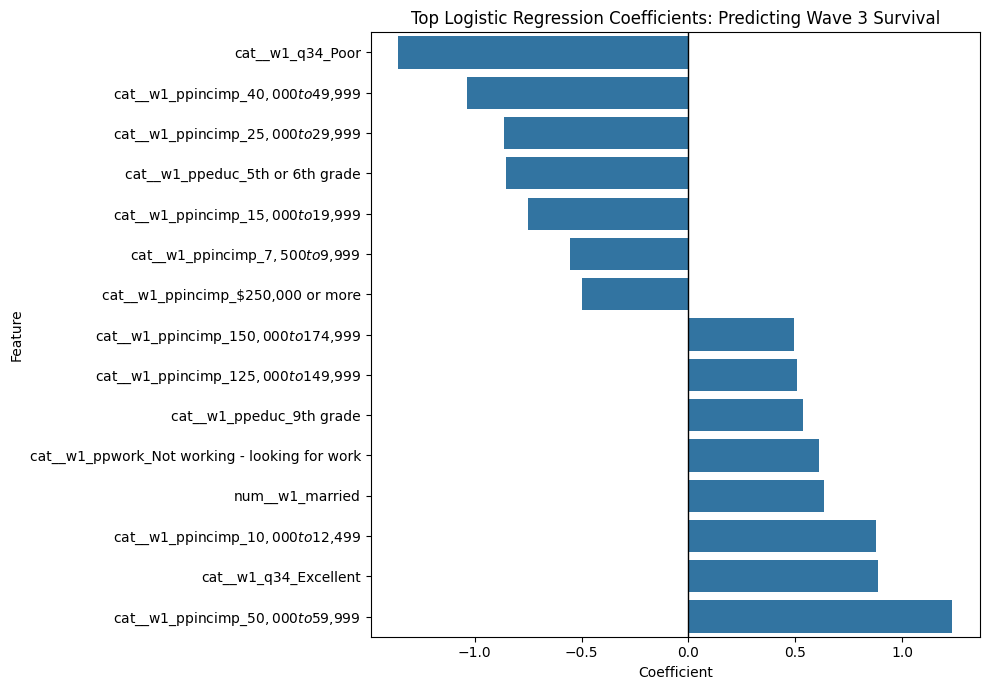

In [50]:
top_coef = coef_df.head(15).sort_values("coefficient")

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_coef,
    x="coefficient",
    y="feature"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Top Logistic Regression Coefficients: Predicting Wave 3 Survival")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "top_logistic_regression_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpreting Model Coefficients

The coefficient plot shows which variables contributed most strongly to the best logistic regression model.

Positive coefficients increase the predicted probability that the relationship survived to Wave 3.  
Negative coefficients decrease the predicted probability of survival.

The strongest positive predictors include:

- excellent Wave 1 relationship quality
- being married at Wave 1
- some income categories

The strongest negative predictors include:

- poor Wave 1 relationship quality
- some lower income categories
- lower education categories

This supports the main conclusion: baseline relationship quality and relationship structure are more informative than meeting online alone.

However, these coefficients should not be interpreted causally. They show associations within this sample, not proof that any variable directly causes relationship survival.

## Recommendations for OKCupid

Based on both the clustering analysis and predictive modelling results, the evidence suggests that long-term relationship success depends more on compatibility and relationship quality than on whether couples first met online or offline.

### Recommendation 1: Prioritize Compatibility Features

OKCupid could continue investing in features that improve compatibility matching, such as:

- shared values
- relationship goals
- communication preferences
- lifestyle alignment

The modelling results suggest that relationship quality is a stronger predictor of long-term survival than meeting context alone.

### Recommendation 2: Support Relationship Readiness

Clusters differed by marital status, relationship duration, age, and life stage. This suggests that users may benefit from matching systems that account for readiness for commitment and long-term goals.

Examples include:

- serious relationship intent filters
- life stage matching
- family planning preferences
- commitment expectations

### Recommendation 3: Do Not Overstate “Meeting Online”

Meeting online showed only modest predictive power.

Therefore, OKCupid should avoid simplistic claims such as:

- “Online dating creates stronger relationships”

Instead, a more evidence-based message would be:

- “The right match matters more than where you meet.”

### Recommendation 4: Improve Early Relationship Success Metrics

Since relationship quality appears highly informative, OKCupid could explore optional post-match feedback systems measuring:

- conversation quality
- mutual engagement
- date satisfaction
- alignment after matching

These metrics may help improve future matching systems.

### Recommendation 5: Use Findings Responsibly

This dataset is observational and based on survey responses. The findings show associations, not causal effects.

Product decisions should therefore use these insights carefully and alongside experimentation and user research.

## Final Conclusion

This project used the longitudinal HCMST dataset to study how couples meet and whether baseline relationship characteristics predict long-term relationship survival.

The clustering analysis identified meaningful relationship profiles that differed across age, marital status, relationship duration, same-sex couple status, meeting context, and relationship quality.

The modelling analysis addressed two main research questions:

1. Does meeting online in Wave 1 predict whether couples remain together in Wave 3?
2. Does relationship quality predict survival better than meeting context?

The results show that meeting online has modest predictive power for long-term relationship survival. However, models including relationship structure and baseline relationship quality performed better.

The strongest predictive model included relationship quality, indicating that the quality of the relationship matters more than whether the couple first met online or offline.

Overall, the findings suggest that successful long-term relationships depend more on compatibility, commitment, and relationship dynamics than on meeting channel alone.

For OKCupid, this implies that product strategy should focus not only on helping users meet, but on helping users build stronger and more compatible relationships after matching.

In [51]:
model_data.to_csv(
    DATA_PROCESSED / "hcmst_wave3_modeling_dataset.csv",
    index=False
)